In [2]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

In [3]:
df = pd.read_csv(
    "train.csv",
    engine="python",
    on_bad_lines="skip"
)


df = df.sample(n=30000, random_state=42)

print(df.shape)

(30000, 6)


In [4]:
df.sample(5)

,id,qid1,qid2,question1,question2,is_duplicate
9742,9742,18919,18920,How much does a captain of the Indian Army get...,What are the cash-in-hand salaries of a: lieut...,0
3032,3032,6011,6012,What is an inanimate object?,What is an inanimate object? What are examples...,1
11450,11450,22110,22111,Why are my all questions marked for improvement?,Why are ALL my questions being marked as needi...,1
29364,29364,54334,54335,What is the font used in the desktop version o...,What font does Twitter use?,0
20401,20401,38489,38490,What would be the best day of your life?,What was the best day of your life? What happe...,1


In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 30000 entries, 6176 to 19045
Data columns (total 6 columns):
 #   Column        Non-Null Count  Dtype 
---  ------        --------------  ----- 
 0   id            30000 non-null  int64 
 1   qid1          30000 non-null  int64 
 2   qid2          30000 non-null  int64 
 3   question1     30000 non-null  object
 4   question2     30000 non-null  object
 5   is_duplicate  30000 non-null  int64 
dtypes: int64(4), object(2)
memory usage: 1.6+ MB


In [6]:
df.isnull().sum()

,0
id,0
qid1,0
qid2,0
question1,0
question2,0
is_duplicate,0


In [7]:
df.duplicated().sum()

np.int64(0)

is_duplicate
0    18828
1    11172
Name: count, dtype: int64
is_duplicate
0    62.76
1    37.24
Name: count, dtype: float64


<Axes: xlabel='is_duplicate'>

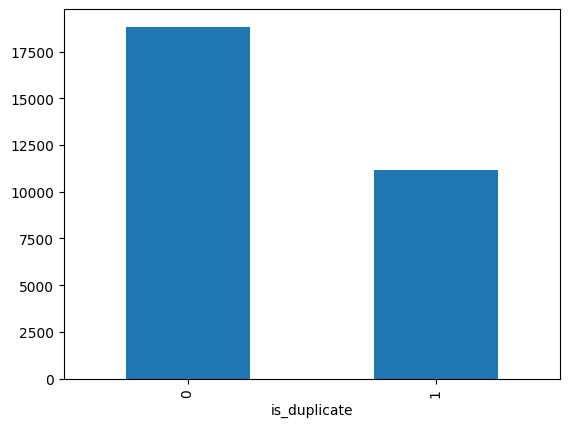

In [8]:
print(df['is_duplicate'].value_counts())
print(df['is_duplicate'].value_counts()/df['is_duplicate'].count()*100)
df["is_duplicate"].value_counts().plot(kind="bar")

In [9]:
#Questions that got repeated

qid = pd.Series(df['qid1'].tolist() + df['qid2'].tolist())
print("Number of unique questions: ", qid.nunique())
print("Number of duplicate questions: ", qid.shape[0] - qid.nunique())

Number of unique questions:  55443
Number of duplicate questions:  4557


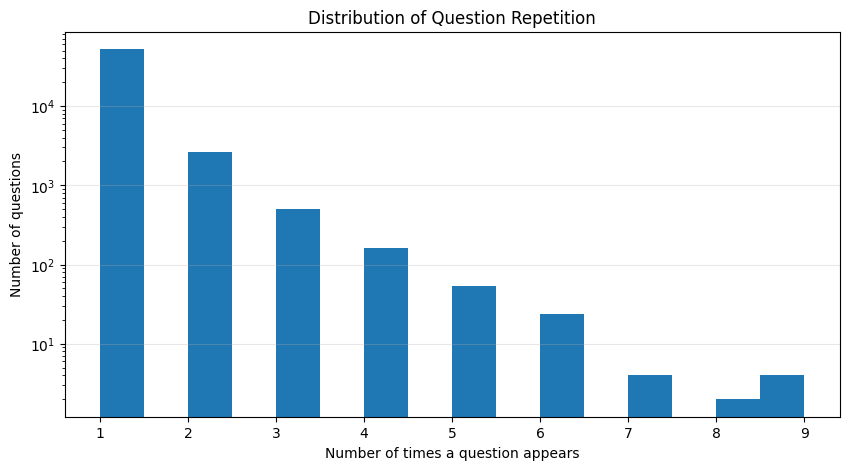

In [10]:
#Repeated question histogram

plt.figure(figsize=(10, 5))

plt.hist(qid.value_counts(), bins=16)

plt.yscale('log')

plt.title("Distribution of Question Repetition")
plt.xlabel("Number of times a question appears")
plt.ylabel("Number of questions")

plt.grid(axis='y', alpha=0.3)

plt.show()

In [11]:
ques_df = df[['question1','question2']]
ques_df.head()

,question1,question2
6176,Does an iPhone reset erase all content and set...,Does erasing all content and settings get rid ...
14630,Should a person dream according to his capabil...,What features make a great exercise bike?
9564,Which is the best IT company?,Which are the best IT companies?
8687,Why is my Miniature Pinscher/Chihuahua mix afr...,Why is my puppy afraid of cats?
13177,What are some TL;DRs of each of the most impor...,What are some TL;DRs of each of the most impor...


In [12]:
ques_df['question1'] = ques_df['question1'].fillna('')
ques_df['question2'] = ques_df['question2'].fillna('')

/tmp/ipykernel_56236/3551104273.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  ques_df['question1'] = ques_df['question1'].fillna('')
/tmp/ipykernel_56236/3551104273.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  ques_df['question2'] = ques_df['question2'].fillna('')


In [13]:
from sklearn.feature_extraction.text import CountVectorizer
#merge texts
questions = list(ques_df['question1']) + list(ques_df['question2'])
len(questions)

cv = CountVectorizer(max_features=3000)
q1_arr, q2_arr = np.vsplit(cv.fit_transform(questions).toarray(),2)



In [14]:
temp_df1 = pd.DataFrame(q1_arr, index= ques_df.index)
temp_df2 = pd.DataFrame(q2_arr, index= ques_df.index)
temp_df = pd.concat([temp_df1, temp_df2], axis=1)
print(temp_df.head())
temp_df.shape


       0     1     2     3     4     5     6     7     8     9     ...  2990  \
6176      0     0     0     0     0     0     0     0     0     0  ...     0   
14630     0     0     0     0     0     0     0     0     0     0  ...     0   
9564      0     0     0     0     0     0     0     0     0     0  ...     0   
8687      0     0     0     0     0     0     0     0     0     0  ...     0   
13177     0     0     0     0     0     0     0     0     0     0  ...     0   

       2991  2992  2993  2994  2995  2996  2997  2998  2999  
6176      0     0     0     0     0     0     0     0     0  
14630     0     0     0     0     0     0     0     0     0  
9564      0     0     0     0     0     0     0     0     0  
8687      0     0     0     0     0     0     0     0     0  
13177     0     0     0     0     0     0     0     0     0  

[5 rows x 6000 columns]


(30000, 6000)

In [15]:
temp_df["is_duplicate"] = df["is_duplicate"]

In [16]:
temp_df

,0,1,2,3,4,5,6,7,8,9,...,2991,2992,2993,2994,2995,2996,2997,2998,2999,is_duplicate
6176,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
14630,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
9564,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,1
8687,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,1
13177,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
21363,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
3253,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,1
28427,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
2064,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0


In [17]:
from sklearn.model_selection import train_test_split
X_train,X_test,y_train,y_test = train_test_split(temp_df.iloc[:,0:-1].values,temp_df.iloc[:,-1].values,test_size=0.2,random_state=1)

In [18]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score
rf = RandomForestClassifier()
rf.fit(X_train,y_train)
y_pred = rf.predict(X_test)
accuracy_score(y_test,y_pred)

0.742

In [19]:
from xgboost import XGBClassifier
xgb = XGBClassifier()
xgb.fit(X_train,y_train)
y_pred = xgb.predict(X_test)
accuracy_score(y_test,y_pred)

0.7201666666666666

In [20]:
# feature engineering

In [21]:
new_df = df[['question1', 'question2', 'is_duplicate']].copy()

In [22]:
new_df['q1_len'] = new_df['question1'].str.len()
new_df['q2_len'] = new_df['question2'].str.len()

In [23]:
new_df.head()

,question1,question2,is_duplicate,q1_len,q2_len
6176,Does an iPhone reset erase all content and set...,Does erasing all content and settings get rid ...,0,52,66
14630,Should a person dream according to his capabil...,What features make a great exercise bike?,0,106,41
9564,Which is the best IT company?,Which are the best IT companies?,1,29,32
8687,Why is my Miniature Pinscher/Chihuahua mix afr...,Why is my puppy afraid of cats?,1,58,31
13177,What are some TL;DRs of each of the most impor...,What are some TL;DRs of each of the most impor...,0,75,73


In [24]:
new_df['q1_num_words'] = new_df['question1'].apply(lambda row: len(row.split(" ")))
new_df['q2_num_words'] = new_df['question2'].apply(lambda row: len(row.split(" ")))
new_df.head()


,question1,question2,is_duplicate,q1_len,q2_len,q1_num_words,q2_num_words
6176,Does an iPhone reset erase all content and set...,Does erasing all content and settings get rid ...,0,52,66,9,12
14630,Should a person dream according to his capabil...,What features make a great exercise bike?,0,106,41,18,7
9564,Which is the best IT company?,Which are the best IT companies?,1,29,32,6,6
8687,Why is my Miniature Pinscher/Chihuahua mix afr...,Why is my puppy afraid of cats?,1,58,31,9,7
13177,What are some TL;DRs of each of the most impor...,What are some TL;DRs of each of the most impor...,0,75,73,13,13


In [25]:
def common_words(row):
    w1 = set(map(lambda word: word.lower().strip(), row['question1'].split(" ")))
    w2 = set(map(lambda word: word.lower().strip(), row['question2'].split(" ")))
    return len(w1 & w2)


In [26]:
new_df['word_common'] = new_df.apply(common_words, axis=1)
new_df.head()

,question1,question2,is_duplicate,q1_len,q2_len,q1_num_words,q2_num_words,word_common
6176,Does an iPhone reset erase all content and set...,Does erasing all content and settings get rid ...,0,52,66,9,12,4
14630,Should a person dream according to his capabil...,What features make a great exercise bike?,0,106,41,18,7,1
9564,Which is the best IT company?,Which are the best IT companies?,1,29,32,6,6,4
8687,Why is my Miniature Pinscher/Chihuahua mix afr...,Why is my puppy afraid of cats?,1,58,31,9,7,6
13177,What are some TL;DRs of each of the most impor...,What are some TL;DRs of each of the most impor...,0,75,73,13,13,10


In [27]:
def total_words(row):
    w1 = set(map(lambda word: word.lower().strip(), row['question1'].split(" ")))
    w2 = set(map(lambda word: word.lower().strip(), row['question2'].split(" ")))
    return (len(w1) + len(w2))

In [28]:
def word_share(row):
    w1 = set(map(lambda word: word.lower().strip(), row['question1'].split(" ")))
    w2 = set(map(lambda word: word.lower().strip(), row['question2'].split(" ")))
    return len(w1 & w2) / (len(w1) + len(w2))

In [29]:
new_df['word_total'] = new_df.apply(total_words, axis=1)

new_df['word_share'] = new_df.apply(word_share, axis=1)

new_df.head()

,question1,question2,is_duplicate,q1_len,q2_len,q1_num_words,q2_num_words,word_common,word_total,word_share
6176,Does an iPhone reset erase all content and set...,Does erasing all content and settings get rid ...,0,52,66,9,12,4,21,0.190476
14630,Should a person dream according to his capabil...,What features make a great exercise bike?,0,106,41,18,7,1,24,0.041667
9564,Which is the best IT company?,Which are the best IT companies?,1,29,32,6,6,4,12,0.333333
8687,Why is my Miniature Pinscher/Chihuahua mix afr...,Why is my puppy afraid of cats?,1,58,31,9,7,6,16,0.375000
13177,What are some TL;DRs of each of the most impor...,What are some TL;DRs of each of the most impor...,0,75,73,13,13,10,22,0.454545


count    30000.000000
mean        59.500067
std         29.931061
min          1.000000
25%         39.000000
50%         52.000000
75%         71.000000
max        413.000000
Name: q1_len, dtype: float64


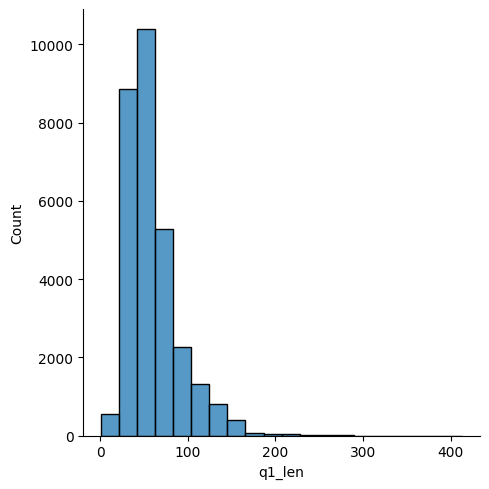

In [30]:
# analysis of feature
sns.displot(new_df, x='q1_len', kde=False, bins=20)
print(new_df['q1_len'].describe())

count    30000.000000
mean        60.056567
std         34.451016
min          6.000000
25%         39.000000
50%         51.000000
75%         71.000000
max       1169.000000
Name: q2_len, dtype: float64


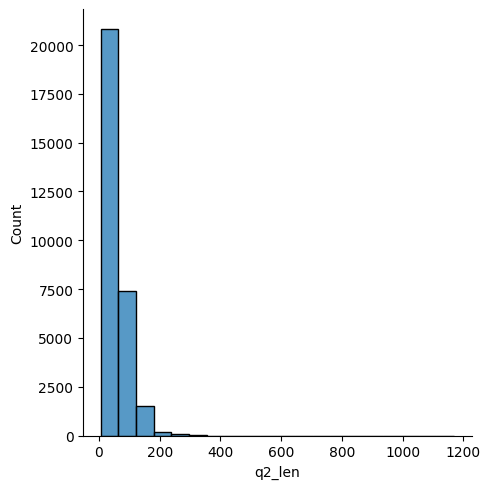

In [31]:
sns.displot(new_df, x='q2_len', kde=False, bins=20)
print(new_df['q2_len'].describe())

count    30000.000000
mean        10.937533
std          5.428046
min          1.000000
25%          7.000000
50%         10.000000
75%         13.000000
max         79.000000
Name: q1_num_words, dtype: float64


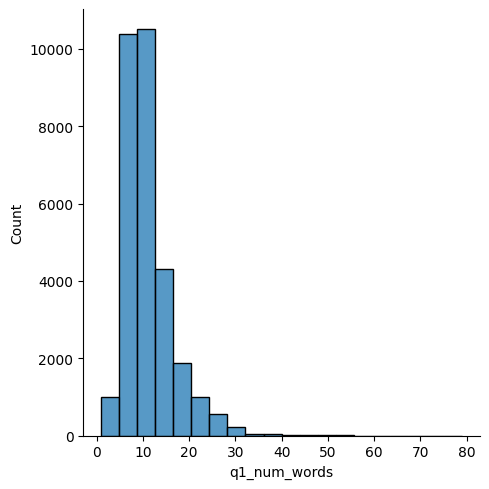

In [32]:
sns.displot(new_df, x='q1_num_words', kde=False, bins=20)
print(new_df['q1_num_words'].describe())

count    30000.000000
mean        11.158933
std          6.419308
min          1.000000
25%          7.000000
50%          9.000000
75%         13.000000
max        237.000000
Name: q2_num_words, dtype: float64


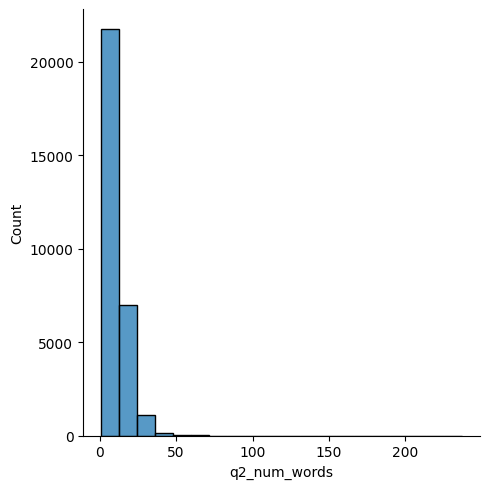

In [33]:
sns.displot(new_df, x='q2_num_words', kde=False, bins=20)
print(new_df['q2_num_words'].describe())

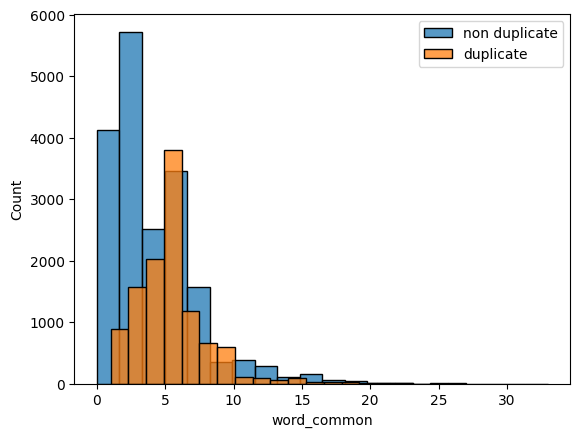

In [34]:
# common words
sns.histplot(
    new_df[new_df['is_duplicate'] == 0]['word_common'],
    label="non duplicate",
    bins=20,
    kde=False
)

sns.histplot(
    new_df[new_df['is_duplicate'] == 1]['word_common'],
    label="duplicate",
    bins=20,
    kde=False
)

plt.legend()
plt.show()

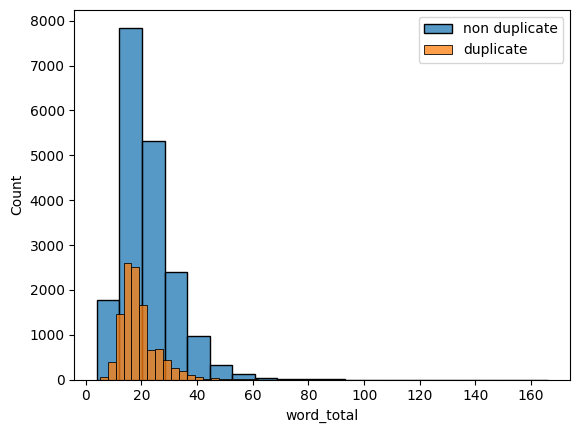

In [35]:
# total words
sns.histplot(
    new_df[new_df['is_duplicate'] == 0]['word_total'],
    label="non duplicate",
    bins=20,
    kde=False
)

sns.histplot(
    new_df[new_df['is_duplicate'] == 1]['word_total'],
    label="duplicate",
    bins=20,
    kde=False
)

plt.legend()
plt.show()

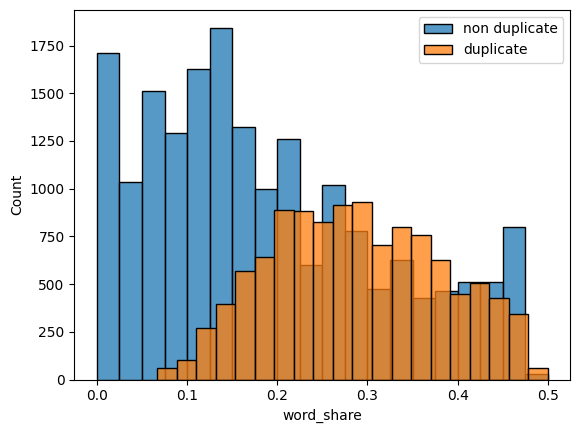

In [36]:
# word_share
sns.histplot(
    new_df[new_df['is_duplicate'] == 0]['word_share'],
    label="non duplicate",
    bins=20,
    kde=False
)

sns.histplot(
    new_df[new_df['is_duplicate'] == 1]['word_share'],
    label="duplicate",
    bins=20,
    kde=False
)

plt.legend()
plt.show()

In [37]:
# new df
ques_df = new_df[['question1', 'question2']]
ques_df.head()

,question1,question2
6176,Does an iPhone reset erase all content and set...,Does erasing all content and settings get rid ...
14630,Should a person dream according to his capabil...,What features make a great exercise bike?
9564,Which is the best IT company?,Which are the best IT companies?
8687,Why is my Miniature Pinscher/Chihuahua mix afr...,Why is my puppy afraid of cats?
13177,What are some TL;DRs of each of the most impor...,What are some TL;DRs of each of the most impor...


In [38]:
final_df = new_df.drop(columns=["question1","question2"])
print(final_df.shape)
final_df.head()

(30000, 8)


,is_duplicate,q1_len,q2_len,q1_num_words,q2_num_words,word_common,word_total,word_share
6176,0,52,66,9,12,4,21,0.190476
14630,0,106,41,18,7,1,24,0.041667
9564,1,29,32,6,6,4,12,0.333333
8687,1,58,31,9,7,6,16,0.375000
13177,0,75,73,13,13,10,22,0.454545


In [39]:
# BOW in question df (merge text)
questions = list(ques_df["question1"]) + list(ques_df["question2"])
cv = CountVectorizer(max_features=3000)
q1_arr, q2_arr = np.vsplit(cv.fit_transform(questions).toarray(),2)

In [40]:
temp_df1 = pd.DataFrame(q1_arr, index= ques_df.index)
temp_df2 = pd.DataFrame(q2_arr, index= ques_df.index)
temp_df = pd.concat([temp_df1, temp_df2], axis=1)
print(temp_df.shape)
temp_df.head()


(30000, 6000)


,0,1,2,3,4,5,6,7,8,9,...,2990,2991,2992,2993,2994,2995,2996,2997,2998,2999
6176,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
14630,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
9564,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
8687,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
13177,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0


In [41]:
final_df = pd.concat([final_df, temp_df], axis=1)
print(final_df.shape)
final_df.head()

(30000, 6008)


,is_duplicate,q1_len,q2_len,q1_num_words,q2_num_words,word_common,word_total,word_share,0,1,...,2990,2991,2992,2993,2994,2995,2996,2997,2998,2999
6176,0,52,66,9,12,4,21,0.190476,0,0,...,0,0,0,0,0,0,0,0,0,0
14630,0,106,41,18,7,1,24,0.041667,0,0,...,0,0,0,0,0,0,0,0,0,0
9564,1,29,32,6,6,4,12,0.333333,0,0,...,0,0,0,0,0,0,0,0,0,0
8687,1,58,31,9,7,6,16,0.375000,0,0,...,0,0,0,0,0,0,0,0,0,0
13177,0,75,73,13,13,10,22,0.454545,0,0,...,0,0,0,0,0,0,0,0,0,0


In [42]:
from sklearn.model_selection import train_test_split
X_train,X_test,y_train,y_test = train_test_split(final_df.iloc[:,1:].values,final_df.iloc[:,0].values,test_size=0.2,random_state=1)

In [43]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score
rf = RandomForestClassifier()
rf.fit(X_train,y_train)
y_pred = rf.predict(X_test)
accuracy_score(y_test,y_pred)

0.7686666666666667

In [44]:
from xgboost import XGBClassifier
xgb = XGBClassifier()
xgb.fit(X_train,y_train)
y_pred = xgb.predict(X_test)
accuracy_score(y_test,y_pred)

0.7645

In [45]:
# preprocessing before feature engineering

clean_df = df[['question1', 'question2', 'is_duplicate']].copy()

# handle missing values
clean_df['question1'] = clean_df['question1'].fillna('')
clean_df['question2'] = clean_df['question2'].fillna('')

# reset index
clean_df = clean_df.reset_index(drop=True)

clean_df.head()

,question1,question2,is_duplicate
0,Does an iPhone reset erase all content and set...,Does erasing all content and settings get rid ...,0
1,Should a person dream according to his capabil...,What features make a great exercise bike?,0
2,Which is the best IT company?,Which are the best IT companies?,1
3,Why is my Miniature Pinscher/Chihuahua mix afr...,Why is my puppy afraid of cats?,1
4,What are some TL;DRs of each of the most impor...,What are some TL;DRs of each of the most impor...,0


In [46]:
import re
from bs4 import BeautifulSoup

def preprocess(q):

    q = str(q).lower().strip()

    # Replace certain special characters with their string equivalents
    q = q.replace('%', ' percent')
    q = q.replace('$', ' dollar ')
    q = q.replace('₹', ' rupee ')
    q = q.replace('€', ' euro ')
    q = q.replace('@', ' at ')

    # The pattern '[math]' appears around 900 times in the whole dataset.
    q = q.replace('[math]', '')

    # Replacing some numbers with string equivalents (not perfect, can be done better to account for more cases)
    q = q.replace(',000,000,000 ', 'b ')
    q = q.replace(',000,000 ', 'm ')
    q = q.replace(',000 ', 'k ')
    q = re.sub(r'([0-9]+)000000000', r'\1b', q)
    q = re.sub(r'([0-9]+)000000', r'\1m', q)
    q = re.sub(r'([0-9]+)000', r'\1k', q)

    # Decontracting words
    # https://en.wikipedia.org/wiki/Wikipedia%3aList_of_English_contractions
    # https://stackoverflow.com/a/19794953
    contractions = {
    "ain't": "am not",
    "aren't": "are not",
    "can't": "can not",
    "can't've": "can not have",
    "'cause": "because",
    "could've": "could have",
    "couldn't": "could not",
    "couldn't've": "could not have",
    "didn't": "did not",
    "doesn't": "does not",
    "don't": "do not",
    "hadn't": "had not",
    "hadn't've": "had not have",
    "hasn't": "has not",
    "haven't": "have not",
    "he'd": "he would",
    "he'd've": "he would have",
    "he'll": "he will",
    "he'll've": "he will have",
    "he's": "he is",
    "how'd": "how did",
    "how'd'y": "how do you",
    "how'll": "how will",
    "how's": "how is",
    "i'd": "i would",
    "i'd've": "i would have",
    "i'll": "i will",
    "i'll've": "i will have",
    "i'm": "i am",
    "i've": "i have",
    "isn't": "is not",
    "it'd": "it would",
    "it'd've": "it would have",
    "it'll": "it will",
    "it'll've": "it will have",
    "it's": "it is",
    "let's": "let us",
    "ma'am": "madam",
    "mayn't": "may not",
    "might've": "might have",
    "mightn't": "might not",
    "mightn't've": "might not have",
    "must've": "must have",
    "mustn't": "must not",
    "mustn't've": "must not have",
    "needn't": "need not",
    "needn't've": "need not have",
    "o'clock": "of the clock",
    "oughtn't": "ought not",
    "oughtn't've": "ought not have",
    "shan't": "shall not",
    "sha'n't": "shall not",
    "shan't've": "shall not have",
    "she'd": "she would",
    "she'd've": "she would have",
    "she'll": "she will",
    "she'll've": "she will have",
    "she's": "she is",
    "should've": "should have",
    "shouldn't": "should not",
    "shouldn't've": "should not have",
    "so've": "so have",
    "so's": "so as",
    "that'd": "that would",
    "that'd've": "that would have",
    "that's": "that is",
    "there'd": "there would",
    "there'd've": "there would have",
    "there's": "there is",
    "they'd": "they would",
    "they'd've": "they would have",
    "they'll": "they will",
    "they'll've": "they will have",
    "they're": "they are",
    "they've": "they have",
    "to've": "to have",
    "wasn't": "was not",
    "we'd": "we would",
    "we'd've": "we would have",
    "we'll": "we will",
    "we'll've": "we will have",
    "we're": "we are",
    "we've": "we have",
    "weren't": "were not",
    "what'll": "what will",
    "what'll've": "what will have",
    "what're": "what are",
    "what's": "what is",
    "what've": "what have",
    "when's": "when is",
    "when've": "when have",
    "where'd": "where did",
    "where's": "where is",
    "where've": "where have",
    "who'll": "who will",
    "who'll've": "who will have",
    "who's": "who is",
    "who've": "who have",
    "why's": "why is",
    "why've": "why have",
    "will've": "will have",
    "won't": "will not",
    "won't've": "will not have",
    "would've": "would have",
    "wouldn't": "would not",
    "wouldn't've": "would not have",
    "y'all": "you all",
    "y'all'd": "you all would",
    "y'all'd've": "you all would have",
    "y'all're": "you all are",
    "y'all've": "you all have",
    "you'd": "you would",
    "you'd've": "you would have",
    "you'll": "you will",
    "you'll've": "you will have",
    "you're": "you are",
    "you've": "you have"
    }

    q_decontracted = []

    for word in q.split():
        if word in contractions:
            word = contractions[word]

        q_decontracted.append(word)

    q = ' '.join(q_decontracted)
    q = q.replace("'ve", " have")
    q = q.replace("n't", " not")
    q = q.replace("'re", " are")
    q = q.replace("'ll", " will")

    # Removing HTML tags
    q = BeautifulSoup(q)
    q = q.get_text()

    # Remove punctuations
    pattern = re.compile('\W')
    q = re.sub(pattern, ' ', q).strip()


    return q

<>:168: SyntaxWarning: invalid escape sequence '\W'
<>:168: SyntaxWarning: invalid escape sequence '\W'
/tmp/ipykernel_56236/1449584115.py:168: SyntaxWarning: invalid escape sequence '\W'
  pattern = re.compile('\W')


In [47]:
clean_df['question1'] = clean_df['question1'].apply(preprocess)
clean_df['question2'] = clean_df['question2'].apply(preprocess)

In [48]:
clean_df.head()

,question1,question2,is_duplicate
0,does an iphone reset erase all content and set...,does erasing all content and settings get rid ...,0
1,should a person dream according to his capabil...,what features make a great exercise bike,0
2,which is the best it company,which are the best it companies,1
3,why is my miniature pinscher chihuahua mix afr...,why is my puppy afraid of cats,1
4,what are some tl drs of each of the most impor...,what are some tl drs of each of the most impor...,0


In [49]:
clean_df['q1_len'] = clean_df['question1'].str.len()
clean_df['q2_len'] = clean_df['question2'].str.len()

In [50]:
clean_df['q1_num_words'] = clean_df['question1'].apply(lambda row: len(row.split(" ")))
clean_df['q2_num_words'] = clean_df['question2'].apply(lambda row: len(row.split(" ")))
clean_df.head()

,question1,question2,is_duplicate,q1_len,q2_len,q1_num_words,q2_num_words
0,does an iphone reset erase all content and set...,does erasing all content and settings get rid ...,0,51,65,9,13
1,should a person dream according to his capabil...,what features make a great exercise bike,0,106,40,19,7
2,which is the best it company,which are the best it companies,1,28,31,6,6
3,why is my miniature pinscher chihuahua mix afr...,why is my puppy afraid of cats,1,57,30,10,7
4,what are some tl drs of each of the most impor...,what are some tl drs of each of the most impor...,0,74,72,14,14


In [51]:
def common_words(row):
    w1 = set(map(lambda word: word.lower().strip(), row['question1'].split(" ")))
    w2 = set(map(lambda word: word.lower().strip(), row['question2'].split(" ")))
    return len(w1 & w2)

In [52]:
clean_df['word_common'] = clean_df.apply(common_words, axis=1)
clean_df.head()

,question1,question2,is_duplicate,q1_len,q2_len,q1_num_words,q2_num_words,word_common
0,does an iphone reset erase all content and set...,does erasing all content and settings get rid ...,0,51,65,9,13,6
1,should a person dream according to his capabil...,what features make a great exercise bike,0,106,40,19,7,1
2,which is the best it company,which are the best it companies,1,28,31,6,6,4
3,why is my miniature pinscher chihuahua mix afr...,why is my puppy afraid of cats,1,57,30,10,7,6
4,what are some tl drs of each of the most impor...,what are some tl drs of each of the most impor...,0,74,72,14,14,11


In [53]:
def total_words(row):
    w1 = set(map(lambda word: word.lower().strip(), row['question1'].split(" ")))
    w2 = set(map(lambda word: word.lower().strip(), row['question2'].split(" ")))
    return (len(w1) + len(w2))

In [54]:
clean_df['word_total'] = clean_df.apply(total_words, axis=1)
clean_df.head()

,question1,question2,is_duplicate,q1_len,q2_len,q1_num_words,q2_num_words,word_common,word_total
0,does an iphone reset erase all content and set...,does erasing all content and settings get rid ...,0,51,65,9,13,6,22
1,should a person dream according to his capabil...,what features make a great exercise bike,0,106,40,19,7,1,25
2,which is the best it company,which are the best it companies,1,28,31,6,6,4,12
3,why is my miniature pinscher chihuahua mix afr...,why is my puppy afraid of cats,1,57,30,10,7,6,17
4,what are some tl drs of each of the most impor...,what are some tl drs of each of the most impor...,0,74,72,14,14,11,24


In [55]:
clean_df['word_share'] = round(clean_df['word_common']/clean_df['word_total'],2)
clean_df.head()

,question1,question2,is_duplicate,q1_len,q2_len,q1_num_words,q2_num_words,word_common,word_total,word_share
0,does an iphone reset erase all content and set...,does erasing all content and settings get rid ...,0,51,65,9,13,6,22,0.27
1,should a person dream according to his capabil...,what features make a great exercise bike,0,106,40,19,7,1,25,0.04
2,which is the best it company,which are the best it companies,1,28,31,6,6,4,12,0.33
3,why is my miniature pinscher chihuahua mix afr...,why is my puppy afraid of cats,1,57,30,10,7,6,17,0.35
4,what are some tl drs of each of the most impor...,what are some tl drs of each of the most impor...,0,74,72,14,14,11,24,0.46


In [56]:
# Advanced Features
from nltk.corpus import stopwords

def fetch_token_features(row):

    q1 = row['question1']
    q2 = row['question2']

    SAFE_DIV = 0.0001

    STOP_WORDS = stopwords.words("english")

    token_features = [0.0]*8

    # Converting the Sentence into Tokens:
    q1_tokens = q1.split()
    q2_tokens = q2.split()

    if len(q1_tokens) == 0 or len(q2_tokens) == 0:
        return token_features

    # Get the non-stopwords in Questions
    q1_words = set([word for word in q1_tokens if word not in STOP_WORDS])
    q2_words = set([word for word in q2_tokens if word not in STOP_WORDS])

    #Get the stopwords in Questions
    q1_stops = set([word for word in q1_tokens if word in STOP_WORDS])
    q2_stops = set([word for word in q2_tokens if word in STOP_WORDS])

    # Get the common non-stopwords from Question pair
    common_word_count = len(q1_words.intersection(q2_words))

    # Get the common stopwords from Question pair
    common_stop_count = len(q1_stops.intersection(q2_stops))

    # Get the common Tokens from Question pair
    common_token_count = len(set(q1_tokens).intersection(set(q2_tokens)))


    token_features[0] = common_word_count / (min(len(q1_words), len(q2_words)) + SAFE_DIV)
    token_features[1] = common_word_count / (max(len(q1_words), len(q2_words)) + SAFE_DIV)
    token_features[2] = common_stop_count / (min(len(q1_stops), len(q2_stops)) + SAFE_DIV)
    token_features[3] = common_stop_count / (max(len(q1_stops), len(q2_stops)) + SAFE_DIV)
    token_features[4] = common_token_count / (min(len(q1_tokens), len(q2_tokens)) + SAFE_DIV)
    token_features[5] = common_token_count / (max(len(q1_tokens), len(q2_tokens)) + SAFE_DIV)

    # Last word of both question is same or not
    token_features[6] = int(q1_tokens[-1] == q2_tokens[-1])

    # First word of both question is same or not
    token_features[7] = int(q1_tokens[0] == q2_tokens[0])

    return token_features

In [57]:
import nltk
nltk.download('stopwords')
token_features = clean_df.apply(fetch_token_features, axis=1)

clean_df["cwc_min"]       = list(map(lambda x: x[0], token_features))
clean_df["cwc_max"]       = list(map(lambda x: x[1], token_features))
clean_df["csc_min"]       = list(map(lambda x: x[2], token_features))
clean_df["csc_max"]       = list(map(lambda x: x[3], token_features))
clean_df["ctc_min"]       = list(map(lambda x: x[4], token_features))
clean_df["ctc_max"]       = list(map(lambda x: x[5], token_features))
clean_df["last_word_eq"]  = list(map(lambda x: x[6], token_features))
clean_df["first_word_eq"] = list(map(lambda x: x[7], token_features))

[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


In [58]:
clean_df.head()

,question1,question2,is_duplicate,q1_len,q2_len,q1_num_words,q2_num_words,word_common,word_total,word_share,cwc_min,cwc_max,csc_min,csc_max,ctc_min,ctc_max,last_word_eq,first_word_eq
0,does an iphone reset erase all content and set...,does erasing all content and settings get rid ...,0,51,65,9,13,6,22,0.27,0.599988,0.428565,0.749981,0.499992,0.666659,0.461535,0.0,1.0
1,should a person dream according to his capabil...,what features make a great exercise bike,0,106,40,19,7,1,25,0.04,0.000000,0.000000,0.499975,0.124998,0.142855,0.052631,0.0,0.0
2,which is the best it company,which are the best it companies,1,28,31,6,6,4,12,0.33,0.499975,0.499975,0.749981,0.749981,0.666656,0.666656,0.0,1.0
3,why is my miniature pinscher chihuahua mix afr...,why is my puppy afraid of cats,1,57,30,10,7,6,17,0.35,0.666644,0.333328,0.999975,0.999975,0.857131,0.599994,1.0,1.0
4,what are some tl drs of each of the most impor...,what are some tl drs of each of the most impor...,0,74,72,14,14,11,24,0.46,0.799984,0.799984,0.999986,0.999986,0.785709,0.785709,0.0,1.0


In [59]:
!pip install distance
import distance

def fetch_length_features(row):

    q1 = row['question1']
    q2 = row['question2']

    length_features = [0.0]*3

    # Converting the Sentence into Tokens:
    q1_tokens = q1.split()
    q2_tokens = q2.split()

    if len(q1_tokens) == 0 or len(q2_tokens) == 0:
        return length_features

    # Absolute length features
    length_features[0] = abs(len(q1_tokens) - len(q2_tokens))

    #Average Token Length of both Questions
    length_features[1] = (len(q1_tokens) + len(q2_tokens))/2

    strs = list(distance.lcsubstrings(q1, q2))
    length_features[2] = len(strs[0]) / (min(len(q1), len(q2)) + 1)

    return length_features

In [60]:
length_features = clean_df.apply(fetch_length_features, axis=1)

clean_df['abs_len_diff'] = list(map(lambda x: x[0], length_features))
clean_df['mean_len'] = list(map(lambda x: x[1], length_features))
clean_df['longest_substr_ratio'] = list(map(lambda x: x[2], length_features))

In [61]:
clean_df.head()

,question1,question2,is_duplicate,q1_len,q2_len,q1_num_words,q2_num_words,word_common,word_total,word_share,...,cwc_max,csc_min,csc_max,ctc_min,ctc_max,last_word_eq,first_word_eq,abs_len_diff,mean_len,longest_substr_ratio
0,does an iphone reset erase all content and set...,does erasing all content and settings get rid ...,0,51,65,9,13,6,22,0.27,...,0.428565,0.749981,0.499992,0.666659,0.461535,0.0,1.0,4.0,11.0,0.480769
1,should a person dream according to his capabil...,what features make a great exercise bike,0,106,40,19,7,1,25,0.04,...,0.000000,0.499975,0.124998,0.142855,0.052631,0.0,0.0,12.0,13.0,0.073171
2,which is the best it company,which are the best it companies,1,28,31,6,6,4,12,0.33,...,0.499975,0.749981,0.749981,0.666656,0.666656,0.0,1.0,0.0,6.0,0.655172
3,why is my miniature pinscher chihuahua mix afr...,why is my puppy afraid of cats,1,57,30,10,7,6,17,0.35,...,0.333328,0.999975,0.999975,0.857131,0.599994,1.0,1.0,3.0,8.5,0.483871
4,what are some tl drs of each of the most impor...,what are some tl drs of each of the most impor...,0,74,72,14,14,11,24,0.46,...,0.799984,0.999986,0.999986,0.785709,0.785709,0.0,1.0,0.0,14.0,0.890411


In [62]:
# Fuzzy Features
!pip install fuzzywuzzy
from fuzzywuzzy import fuzz

def fetch_fuzzy_features(row):

    q1 = row['question1']
    q2 = row['question2']

    fuzzy_features = [0.0]*4

    # fuzz_ratio
    fuzzy_features[0] = fuzz.QRatio(q1, q2)

    # fuzz_partial_ratio
    fuzzy_features[1] = fuzz.partial_ratio(q1, q2)

    # token_sort_ratio
    fuzzy_features[2] = fuzz.token_sort_ratio(q1, q2)

    # token_set_ratio
    fuzzy_features[3] = fuzz.token_set_ratio(q1, q2)

    return fuzzy_features

/usr/local/lib/python3.13/dist-packages/fuzzywuzzy/fuzz.py:11: UserWarning: Using slow pure-python SequenceMatcher. Install python-Levenshtein to remove this warning
  warnings.warn('Using slow pure-python SequenceMatcher. Install python-Levenshtein to remove this warning')


In [63]:
fuzzy_features = clean_df.apply(fetch_fuzzy_features, axis=1)

# Creating new feature columns for fuzzy features
clean_df['fuzz_ratio'] = list(map(lambda x: x[0], fuzzy_features))
clean_df['fuzz_partial_ratio'] = list(map(lambda x: x[1], fuzzy_features))
clean_df['token_sort_ratio'] = list(map(lambda x: x[2], fuzzy_features))
clean_df['token_set_ratio'] = list(map(lambda x: x[3], fuzzy_features))

In [64]:
print(clean_df.shape)
clean_df.head()

(30000, 25)


,question1,question2,is_duplicate,q1_len,q2_len,q1_num_words,q2_num_words,word_common,word_total,word_share,...,ctc_max,last_word_eq,first_word_eq,abs_len_diff,mean_len,longest_substr_ratio,fuzz_ratio,fuzz_partial_ratio,token_sort_ratio,token_set_ratio
0,does an iphone reset erase all content and set...,does erasing all content and settings get rid ...,0,51,65,9,13,6,22,0.27,...,0.461535,0.0,1.0,4.0,11.0,0.480769,59,67,78,83
1,should a person dream according to his capabil...,what features make a great exercise bike,0,106,40,19,7,1,25,0.04,...,0.052631,0.0,0.0,12.0,13.0,0.073171,21,38,22,22
2,which is the best it company,which are the best it companies,1,28,31,6,6,4,12,0.33,...,0.666656,0.0,1.0,0.0,6.0,0.655172,85,89,88,88
3,why is my miniature pinscher chihuahua mix afr...,why is my puppy afraid of cats,1,57,30,10,7,6,17,0.35,...,0.599994,1.0,1.0,3.0,8.5,0.483871,62,63,60,89
4,what are some tl drs of each of the most impor...,what are some tl drs of each of the most impor...,0,74,72,14,14,11,24,0.46,...,0.785709,0.0,1.0,0.0,14.0,0.890411,95,94,95,94


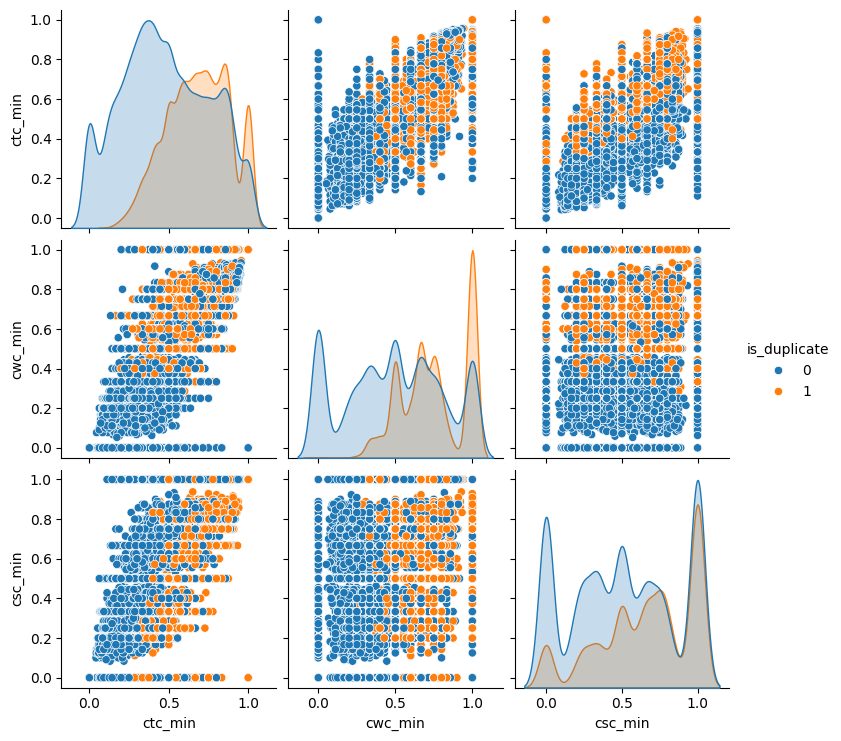

In [65]:
sns.pairplot(clean_df[['ctc_min', 'cwc_min', 'csc_min', 'is_duplicate']],hue='is_duplicate')

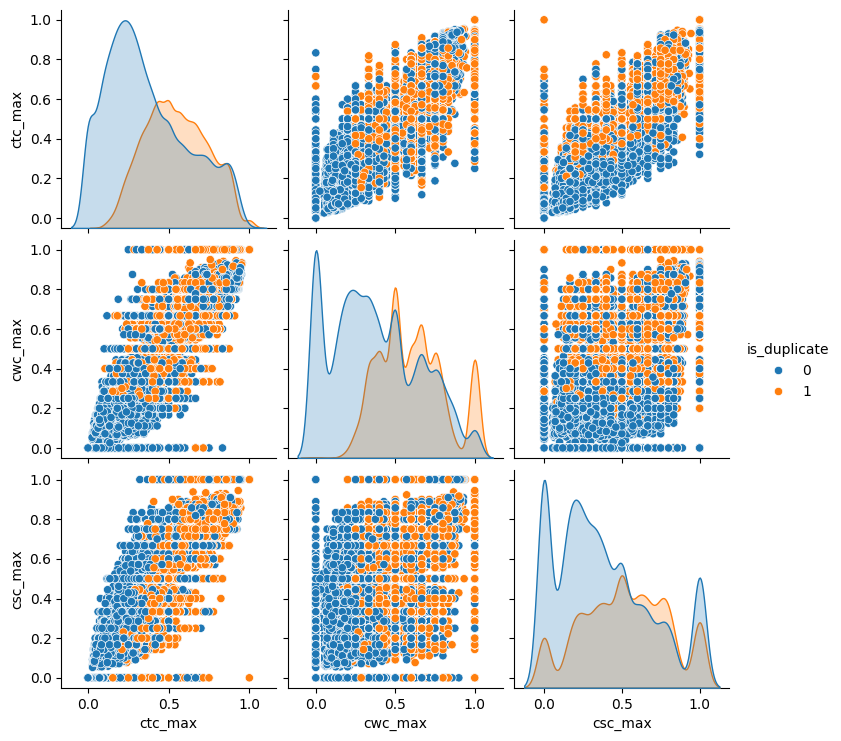

In [66]:
sns.pairplot(clean_df[['ctc_max', 'cwc_max', 'csc_max', 'is_duplicate']],hue='is_duplicate')

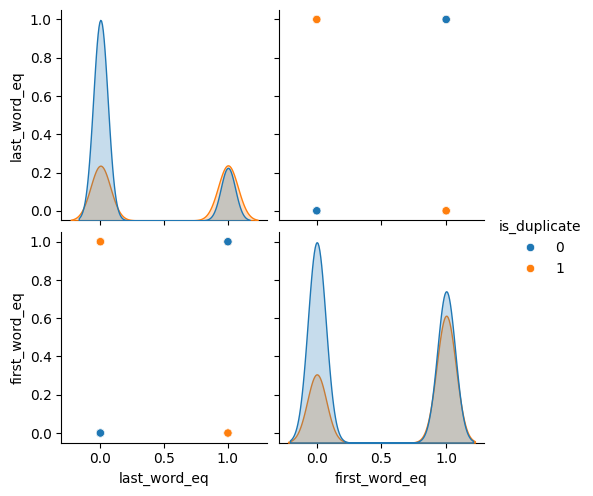

In [67]:
sns.pairplot(clean_df[['last_word_eq', 'first_word_eq', 'is_duplicate']],hue='is_duplicate')

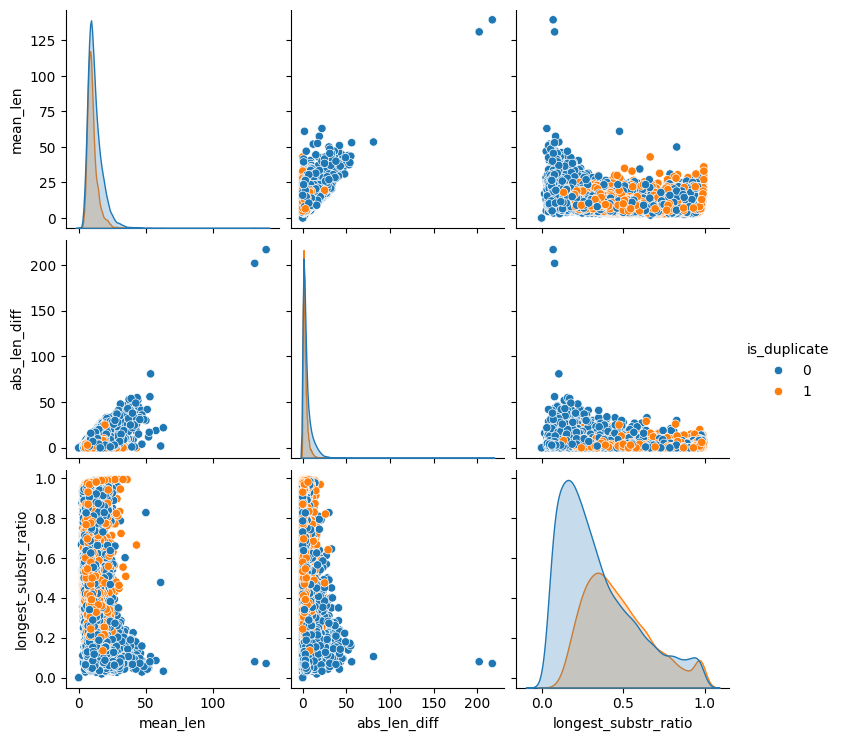

In [68]:
sns.pairplot(clean_df[['mean_len', 'abs_len_diff','longest_substr_ratio', 'is_duplicate']],hue='is_duplicate')

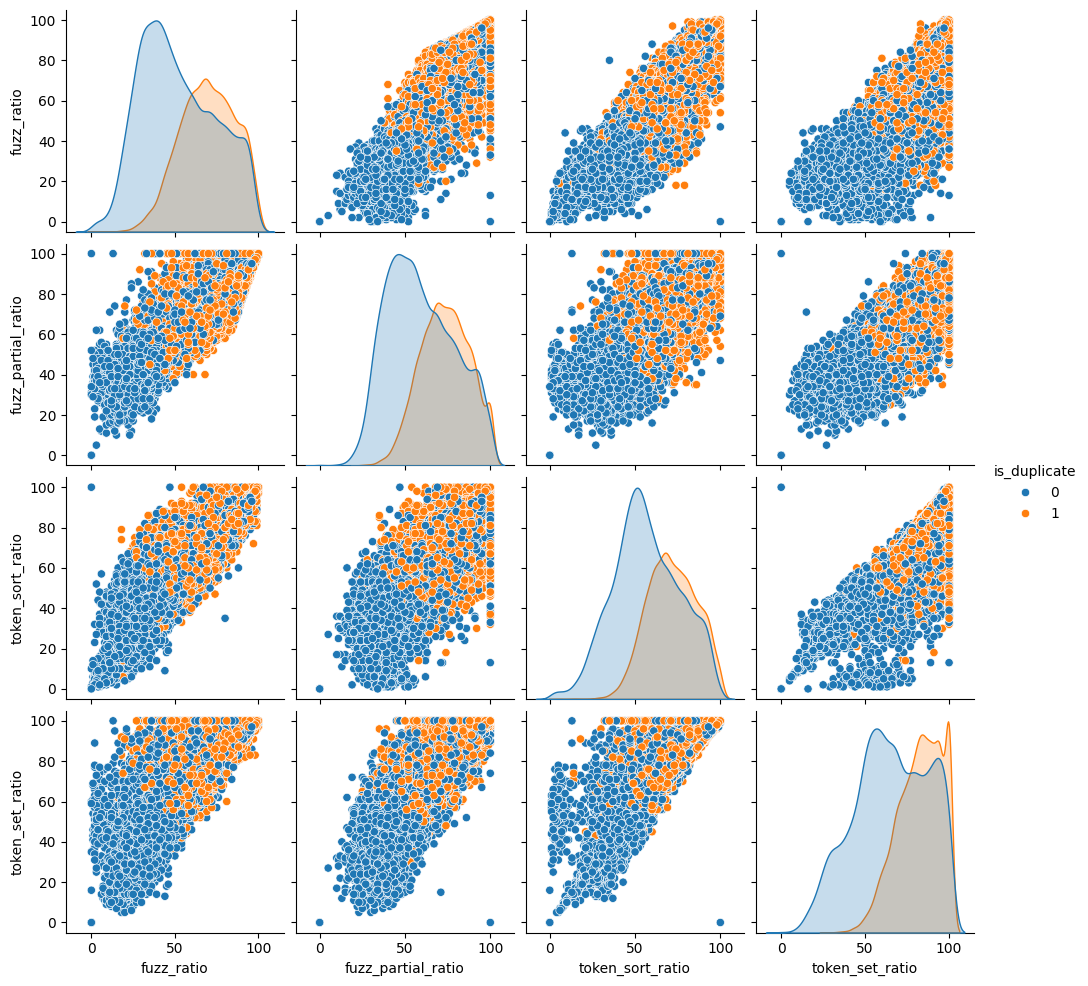

In [69]:
sns.pairplot(clean_df[['fuzz_ratio', 'fuzz_partial_ratio','token_sort_ratio','token_set_ratio', 'is_duplicate']],hue='is_duplicate')

In [70]:
# Using TSNE for Dimentionality reduction for 15 Features(Generated after cleaning the data) to 3 dimention

from sklearn.preprocessing import MinMaxScaler

X = MinMaxScaler().fit_transform(clean_df[['cwc_min', 'cwc_max', 'csc_min', 'csc_max' , 'ctc_min' , 'ctc_max' , 'last_word_eq', 'first_word_eq' , 'abs_len_diff' , 'mean_len' , 'token_set_ratio' , 'token_sort_ratio' ,  'fuzz_ratio' , 'fuzz_partial_ratio' , 'longest_substr_ratio']])
y = clean_df['is_duplicate'].values

In [ ]:
from sklearn.manifold import TSNE

tsne2d = TSNE(
    n_components=2,
    init='random', # pca
    random_state=101,
    method='barnes_hut',
    n_iter=1000,
    verbose=2,
    angle=0.5
).fit_transform(X)

/usr/local/lib/python3.13/dist-packages/sklearn/manifold/_t_sne.py:1164: FutureWarning: 'n_iter' was renamed to 'max_iter' in version 1.5 and will be removed in 1.7.
  warnings.warn(


[t-SNE] Computing 91 nearest neighbors...
[t-SNE] Indexed 30000 samples in 0.066s...
[t-SNE] Computed neighbors for 30000 samples in 6.489s...
[t-SNE] Computed conditional probabilities for sample 1000 / 30000
[t-SNE] Computed conditional probabilities for sample 2000 / 30000
[t-SNE] Computed conditional probabilities for sample 3000 / 30000
[t-SNE] Computed conditional probabilities for sample 4000 / 30000
[t-SNE] Computed conditional probabilities for sample 5000 / 30000
[t-SNE] Computed conditional probabilities for sample 6000 / 30000
[t-SNE] Computed conditional probabilities for sample 7000 / 30000
[t-SNE] Computed conditional probabilities for sample 8000 / 30000
[t-SNE] Computed conditional probabilities for sample 9000 / 30000
[t-SNE] Computed conditional probabilities for sample 10000 / 30000
[t-SNE] Computed conditional probabilities for sample 11000 / 30000
[t-SNE] Computed conditional probabilities for sample 12000 / 30000
[t-SNE] Computed conditional probabilities for sam

In [ ]:
x_df = pd.DataFrame({'x':tsne2d[:,0], 'y':tsne2d[:,1] ,'label':y})

# draw the plot in appropriate place in the grid
sns.lmplot(
    data=x_df,
    x='x',
    y='y',
    hue='label',
    fit_reg=False,
    height=8,
    palette="Set1",
    markers=['s','o']
)

In [ ]:
tsne3d = TSNE(
    n_components=3,
    init='random', # pca
    random_state=101,
    method='barnes_hut',
    n_iter=1000,
    verbose=2,
    angle=0.5
).fit_transform(X)

In [ ]:
import plotly.graph_objs as go
import plotly.tools as tls
import plotly.offline as py
py.init_notebook_mode(connected=True)

trace1 = go.Scatter3d(
    x=tsne3d[:,0],
    y=tsne3d[:,1],
    z=tsne3d[:,2],
    mode='markers',
    marker=dict(
        sizemode='diameter',
        color = y,
        colorscale = 'Portland',
        colorbar = dict(title = 'duplicate'),
        line=dict(color='rgb(255, 255, 255)'),
        opacity=0.75
    )
)

data=[trace1]
layout=dict(height=800, width=800, title='3d embedding with engineered features')
fig=dict(data=data, layout=layout)
py.iplot(fig, filename='3DBubble')

In [ ]:
question_df = clean_df[['question1','question2']]
question_df.head()

In [ ]:
final_df = clean_df.drop(columns=['question1','question2'])
print(final_df.shape)
final_df.head()

In [ ]:
from sklearn.feature_extraction.text import CountVectorizer
# merge texts
questions = list(question_df['question1']) + list(question_df['question2'])

cv = CountVectorizer(max_features=3000)
q1_arr, q2_arr = np.vsplit(cv.fit_transform(questions).toarray(),2)

In [ ]:
temp_df1 = pd.DataFrame(q1_arr, index= ques_df.index)
temp_df2 = pd.DataFrame(q2_arr, index= ques_df.index)
temp_df = pd.concat([temp_df1, temp_df2], axis=1)
temp_df.shape

In [ ]:
final_df = pd.concat([final_df, temp_df], axis=1)
print(final_df.shape)
final_df.head()

In [ ]:
from sklearn.model_selection import train_test_split
X_train,X_test,y_train,y_test = train_test_split(final_df.iloc[:,1:].values,final_df.iloc[:,0].values,test_size=0.2,random_state=1)


In [ ]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score
rf = RandomForestClassifier()
rf.fit(X_train,y_train)
y_pred = rf.predict(X_test)
accuracy_score(y_test,y_pred)

In [ ]:
from xgboost import XGBClassifier
xgb = XGBClassifier()
xgb.fit(X_train,y_train)
y_pred1 = xgb.predict(X_test)
accuracy_score(y_test,y_pred1)

In [ ]:
from sklearn.metrics import confusion_matrix

In [ ]:
# for random forest model
confusion_matrix(y_test,y_pred)

In [ ]:
# for xgboost model
confusion_matrix(y_test,y_pred1)

In [ ]:
def test_common_words(q1,q2):
    w1 = set(map(lambda word: word.lower().strip(), q1.split(" ")))
    w2 = set(map(lambda word: word.lower().strip(), q2.split(" ")))
    return len(w1 & w2)

In [ ]:
def test_total_words(q1,q2):
    w1 = set(map(lambda word: word.lower().strip(), q1.split(" ")))
    w2 = set(map(lambda word: word.lower().strip(), q2.split(" ")))
    return (len(w1) + len(w2))

In [ ]:
def test_fetch_token_features(q1,q2):

    SAFE_DIV = 0.0001

    STOP_WORDS = stopwords.words("english")

    token_features = [0.0]*8

    # Converting the Sentence into Tokens:
    q1_tokens = q1.split()
    q2_tokens = q2.split()

    if len(q1_tokens) == 0 or len(q2_tokens) == 0:
        return token_features

    # Get the non-stopwords in Questions
    q1_words = set([word for word in q1_tokens if word not in STOP_WORDS])
    q2_words = set([word for word in q2_tokens if word not in STOP_WORDS])

    #Get the stopwords in Questions
    q1_stops = set([word for word in q1_tokens if word in STOP_WORDS])
    q2_stops = set([word for word in q2_tokens if word in STOP_WORDS])

    # Get the common non-stopwords from Question pair
    common_word_count = len(q1_words.intersection(q2_words))

    # Get the common stopwords from Question pair
    common_stop_count = len(q1_stops.intersection(q2_stops))

    # Get the common Tokens from Question pair
    common_token_count = len(set(q1_tokens).intersection(set(q2_tokens)))

    token_features[0] = common_word_count / (min(len(q1_words), len(q2_words)) + SAFE_DIV)
    token_features[1] = common_word_count / (max(len(q1_words), len(q2_words)) + SAFE_DIV)
    token_features[2] = common_stop_count / (min(len(q1_stops), len(q2_stops)) + SAFE_DIV)
    token_features[3] = common_stop_count / (max(len(q1_stops), len(q2_stops)) + SAFE_DIV)
    token_features[4] = common_token_count / (min(len(q1_tokens), len(q2_tokens)) + SAFE_DIV)
    token_features[5] = common_token_count / (max(len(q1_tokens), len(q2_tokens)) + SAFE_DIV)

    # Last word of both question is same or not
    token_features[6] = int(q1_tokens[-1] == q2_tokens[-1])

    # First word of both question is same or not
    token_features[7] = int(q1_tokens[0] == q2_tokens[0])

    return token_features

In [ ]:
def test_fetch_length_features(q1,q2):

    length_features = [0.0]*3

    # Converting the Sentence into Tokens:
    q1_tokens = q1.split()
    q2_tokens = q2.split()

    if len(q1_tokens) == 0 or len(q2_tokens) == 0:
        return length_features

    # Absolute length features
    length_features[0] = abs(len(q1_tokens) - len(q2_tokens))

    #Average Token Length of both Questions
    length_features[1] = (len(q1_tokens) + len(q2_tokens))/2

    strs = list(distance.lcsubstrings(q1, q2))
    length_features[2] = len(strs[0]) / (min(len(q1), len(q2)) + 1)

    return length_features

In [ ]:
def test_fetch_fuzzy_features(q1,q2):

    fuzzy_features = [0.0]*4

    # fuzz_ratio
    fuzzy_features[0] = fuzz.QRatio(q1, q2)

    # fuzz_partial_ratio
    fuzzy_features[1] = fuzz.partial_ratio(q1, q2)

    # token_sort_ratio
    fuzzy_features[2] = fuzz.token_sort_ratio(q1, q2)

    # token_set_ratio
    fuzzy_features[3] = fuzz.token_set_ratio(q1, q2)

    return fuzzy_features

In [ ]:
def query_point_creator(q1,q2):

    input_query = []

    # preprocess
    q1 = preprocess(q1)
    q2 = preprocess(q2)

    # fetch basic features
    input_query.append(len(q1))
    input_query.append(len(q2))

    input_query.append(len(q1.split(" ")))
    input_query.append(len(q2.split(" ")))

    input_query.append(test_common_words(q1,q2))
    input_query.append(test_total_words(q1,q2))
    input_query.append(round(test_common_words(q1,q2)/test_total_words(q1,q2),2))

    # fetch token features
    token_features = test_fetch_token_features(q1,q2)
    input_query.extend(token_features)

    # fetch length based features
    length_features = test_fetch_length_features(q1,q2)
    input_query.extend(length_features)

    # fetch fuzzy features
    fuzzy_features = test_fetch_fuzzy_features(q1,q2)
    input_query.extend(fuzzy_features)

    # bow feature for q1
    q1_bow = cv.transform([q1]).toarray()

    # bow feature for q2
    q2_bow = cv.transform([q2]).toarray()



    return np.hstack((np.array(input_query).reshape(1,22),q1_bow,q2_bow))

In [ ]:
import pickle

pickle.dump(rf,open('model.pkl','wb'))
pickle.dump(cv,open('cv.pkl','wb'))